# New Agreement Analysis

Fresh notebook for Experiment 1 corrected results. This starts with model-by-evaluator Spearman agreement against GPT-5.4.

In [25]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False

RESULTS_DIR = Path("results /experiment 1")
CORRECTED_DIR = Path("results /experiment 1 corrected")
GPT_PATH = RESULTS_DIR / "gpt-5.4.csv"

KEY_COLUMNS = ["trace_id", "evaluator", "level"]

plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 200
pd.set_option("display.max_columns", 100)


In [26]:
def add_job_identity(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["occurrence_index"] = df.groupby(KEY_COLUMNS).cumcount()
    df["job_id"] = (
        df["trace_id"].astype(str)
        + "|"
        + df["evaluator"].astype(str)
        + "|"
        + df["level"].astype(str)
        + "|"
        + df["occurrence_index"].astype(str)
    )
    return df


def skipped_mask(df: pd.DataFrame) -> pd.Series:
    return df["is_skipped"].fillna(False).astype(str).str.lower().isin({"true", "1", "yes"})


def clean_model_name(name: str) -> str:
    replacements = {
        "Qwen/Qwen3.5-2B": "Qwen3.5-2B",
        "Qwen/Qwen3.5-4B": "Qwen3.5-4B",
        "Qwen/Qwen3.5-9B": "Qwen3.5-9B",
        "google/gemma-3-4b-it": "Gemma-3-4B-it",
        "microsoft/Phi-4-mini-instruct": "Phi-4-mini",
        "meta-llama/Meta-Llama-3.1-8B-Instruct": "Llama-3.1-8B",
    }
    return replacements.get(str(name), str(name))


def load_scores(path: Path, score_col: str) -> pd.DataFrame:
    df = add_job_identity(pd.read_csv(path))
    df[score_col] = pd.to_numeric(df["score"], errors="coerce")
    keep = ~skipped_mask(df) & df[score_col].between(0, 1)
    return df.loc[keep, ["job_id", "trace_id", "evaluator", "level", "occurrence_index", score_col]].copy()


In [27]:
gpt = load_scores(GPT_PATH, "gpt_score")

model_paths = sorted(CORRECTED_DIR.glob("*.csv"))
model_frames = {}
model_names = {}

for path in model_paths:
    df_raw = pd.read_csv(path, nrows=1)
    model_id = df_raw["model"].iloc[0]
    if model_id == "gpt-5.4":
        continue
    scores = load_scores(path, "slm_score")
    model_frames[model_id] = scores
    model_names[model_id] = clean_model_name(model_id)

# Complete-case analysis: if a job is skipped/missing for any included SLM, drop it for all models and GPT.
common_job_ids = set(gpt["job_id"])
for scores in model_frames.values():
    common_job_ids &= set(scores["job_id"])
common_job_ids = sorted(common_job_ids)
print(f"Complete-case jobs retained: {len(common_job_ids)} / {len(gpt)}")

rows = []
for model_id, slm in model_frames.items():
    slm_common = slm[slm["job_id"].isin(common_job_ids)]
    gpt_common = gpt[gpt["job_id"].isin(common_job_ids)]
    merged = slm_common.merge(gpt_common[["job_id", "gpt_score"]], on="job_id", how="inner")

    for (evaluator, level), group in merged.groupby(["evaluator", "level"]):
        if len(group) < 3:
            continue
        rows.append(
            {
                "model": model_id,
                "model_display": model_names[model_id],
                "file": next(path.name for path in model_paths if pd.read_csv(path, nrows=1)["model"].iloc[0] == model_id),
                "evaluator": evaluator,
                "level": level,
                "evaluator_display": f"{evaluator} / {level}",
                "n": len(group),
                "pearson": group["slm_score"].corr(group["gpt_score"], method="pearson"),
                "spearman": group["slm_score"].corr(group["gpt_score"], method="spearman"),
                "mean_delta": (group["slm_score"] - group["gpt_score"]).mean(),
                "mae": (group["slm_score"] - group["gpt_score"]).abs().mean(),
            }
        )

corr_df = pd.DataFrame(rows).sort_values(["model_display", "evaluator_display"])
corr_df


Complete-case jobs retained: 934 / 939


,model,model_display,file,evaluator,level,evaluator_display,n,pearson,spearman,mean_delta,mae
15,google/gemma-3-4b-it,Gemma-3-4B-it,google_gemma-3-4b-it.csv,accuracy,trace,accuracy / trace,117,0.158417,0.129114,-0.211538,0.391026
16,google/gemma-3-4b-it,Gemma-3-4B-it,google_gemma-3-4b-it.csv,groundedness,trace,groundedness / trace,117,0.248389,0.126194,0.021368,0.149573
17,google/gemma-3-4b-it,Gemma-3-4B-it,google_gemma-3-4b-it.csv,helpfulness,trace,helpfulness / trace,117,0.185498,0.202841,0.334188,0.375214
18,google/gemma-3-4b-it,Gemma-3-4B-it,google_gemma-3-4b-it.csv,instruction_following,agent,instruction_following / agent,291,0.495561,0.551390,-0.061168,0.199313
19,google/gemma-3-4b-it,Gemma-3-4B-it,google_gemma-3-4b-it.csv,reasoning_quality,agent,reasoning_quality / agent,292,0.741820,0.831153,0.038938,0.140240
20,microsoft/Phi-4-mini-instruct,Phi-4-mini,phi-4-mini-instruct.csv,accuracy,trace,accuracy / trace,117,0.133964,0.139310,-0.235043,0.427350
21,microsoft/Phi-4-mini-instruct,Phi-4-mini,phi-4-mini-instruct.csv,groundedness,trace,groundedness / trace,117,0.380431,0.351640,-0.002137,0.113248
22,microsoft/Phi-4-mini-instruct,Phi-4-mini,phi-4-mini-instruct.csv,helpfulness,trace,helpfulness / trace,117,0.222809,0.270156,0.582051,0.594872
23,microsoft/Phi-4-mini-instruct,Phi-4-mini,phi-4-mini-instruct.csv,instruction_following,agent,instruction_following / agent,291,-0.357243,-0.464330,0.196821,0.550430
24,microsoft/Phi-4-mini-instruct,Phi-4-mini,phi-4-mini-instruct.csv,reasoning_quality,agent,reasoning_quality / agent,292,0.729288,0.768624,0.135000,0.201336


In [28]:
heatmap_data = corr_df.pivot(index="model_display", columns="evaluator_display", values="spearman")
count_data = corr_df.pivot(index="model_display", columns="evaluator_display", values="n")

preferred_models = ["Qwen3.5-2B", "Qwen3.5-4B", "Qwen3.5-9B", "Gemma-3-4B-it", "Phi-4-mini", "Llama-3.1-8B"]
preferred_evaluators = [
    "accuracy / trace",
    "groundedness / trace",
    "helpfulness / trace",
    "instruction_following / agent",
    "reasoning_quality / agent",
]
heatmap_data = heatmap_data.reindex(index=[m for m in preferred_models if m in heatmap_data.index])
heatmap_data = heatmap_data.reindex(columns=[c for c in preferred_evaluators if c in heatmap_data.columns])
count_data = count_data.reindex(index=heatmap_data.index, columns=heatmap_data.columns)

annot = heatmap_data.copy().astype(object)
for row in heatmap_data.index:
    for col in heatmap_data.columns:
        val = heatmap_data.loc[row, col]
        n = count_data.loc[row, col]
        annot.loc[row, col] = "" if pd.isna(val) else f"{val:.2f}\nn={int(n)}"


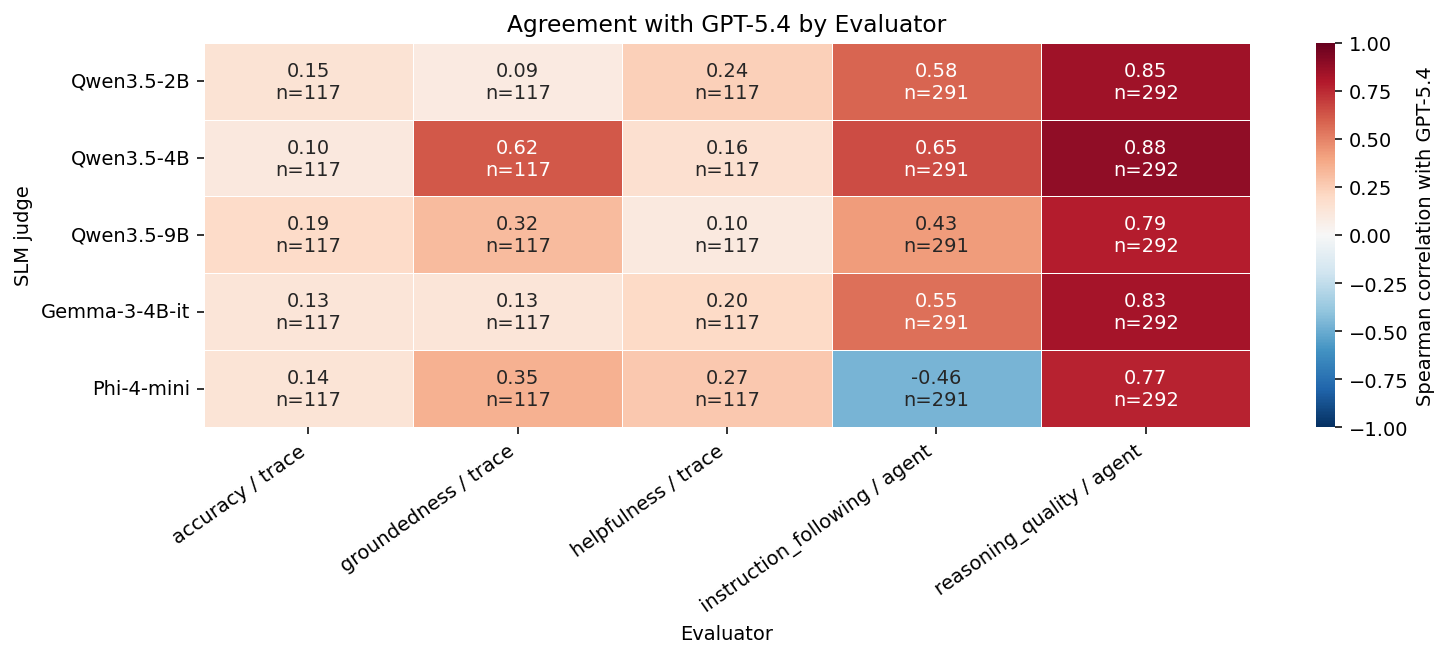

In [29]:
fig_dir = Path("results /figures")
fig_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(11, 4.8))
if HAS_SEABORN:
    sns.heatmap(
        heatmap_data,
        annot=annot,
        fmt="",
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
        center=0,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Spearman correlation with GPT-5.4"},
        ax=ax,
    )
else:
    im = ax.imshow(heatmap_data.values, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(heatmap_data.columns)), heatmap_data.columns, rotation=35, ha="right")
    ax.set_yticks(range(len(heatmap_data.index)), heatmap_data.index)
    for i, row in enumerate(heatmap_data.index):
        for j, col in enumerate(heatmap_data.columns):
            label = annot.loc[row, col]
            if label:
                ax.text(j, i, label, ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, label="Spearman correlation with GPT-5.4")

ax.set_xlabel("Evaluator")
ax.set_ylabel("SLM judge")
ax.set_title("Agreement with GPT-5.4 by Evaluator")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
fig.savefig(fig_dir / "experiment1_shared_set_spearman_heatmap.png", bbox_inches="tight")
fig.savefig(fig_dir / "experiment1_shared_set_spearman_heatmap.pdf", bbox_inches="tight")
plt.show()


## Delta Density Distributions

Each curve shows the distribution of row-level disagreement: `SLM score - GPT-5.4 score`. Curves centered near zero indicate low bias; wider curves indicate more variance in disagreement.

In [31]:
delta_rows = []
for model_id, slm in model_frames.items():
    slm_common = slm[slm["job_id"].isin(common_job_ids)]
    gpt_common = gpt[gpt["job_id"].isin(common_job_ids)]
    merged = slm_common.merge(gpt_common[["job_id", "gpt_score"]], on="job_id", how="inner")
    merged["delta"] = merged["slm_score"] - merged["gpt_score"]
    merged["abs_delta"] = merged["delta"].abs()
    merged["model"] = model_id
    merged["model_display"] = model_names[model_id]
    merged["evaluator_display"] = merged["evaluator"] + " / " + merged["level"]
    delta_rows.append(merged)

delta_df = pd.concat(delta_rows, ignore_index=True)

delta_summary = (
    delta_df.groupby(["model_display", "evaluator_display"])
    .agg(
        n=("delta", "size"),
        mean_delta=("delta", "mean"),
        std_delta=("delta", "std"),
        var_delta=("delta", "var"),
        mae=("abs_delta", "mean"),
        within_025=("abs_delta", lambda s: (s <= 0.25).mean()),
    )
    .reset_index()
)

delta_summary.round(3)


,model_display,evaluator_display,n,mean_delta,std_delta,var_delta,mae,within_025
0,Gemma-3-4B-it,accuracy / trace,117,-0.212,0.485,0.236,0.391,0.530
1,Gemma-3-4B-it,groundedness / trace,117,0.021,0.342,0.117,0.150,0.829
2,Gemma-3-4B-it,helpfulness / trace,117,0.334,0.400,0.160,0.375,0.590
3,Gemma-3-4B-it,instruction_following / agent,291,-0.061,0.302,0.091,0.199,0.808
4,Gemma-3-4B-it,reasoning_quality / agent,292,0.039,0.228,0.052,0.140,0.839
5,Phi-4-mini,accuracy / trace,117,-0.235,0.527,0.277,0.427,0.496
6,Phi-4-mini,groundedness / trace,117,-0.002,0.302,0.091,0.113,0.863
7,Phi-4-mini,helpfulness / trace,117,0.582,0.475,0.225,0.595,0.368
8,Phi-4-mini,instruction_following / agent,291,0.197,0.625,0.391,0.550,0.395
9,Phi-4-mini,reasoning_quality / agent,292,0.135,0.280,0.078,0.201,0.733


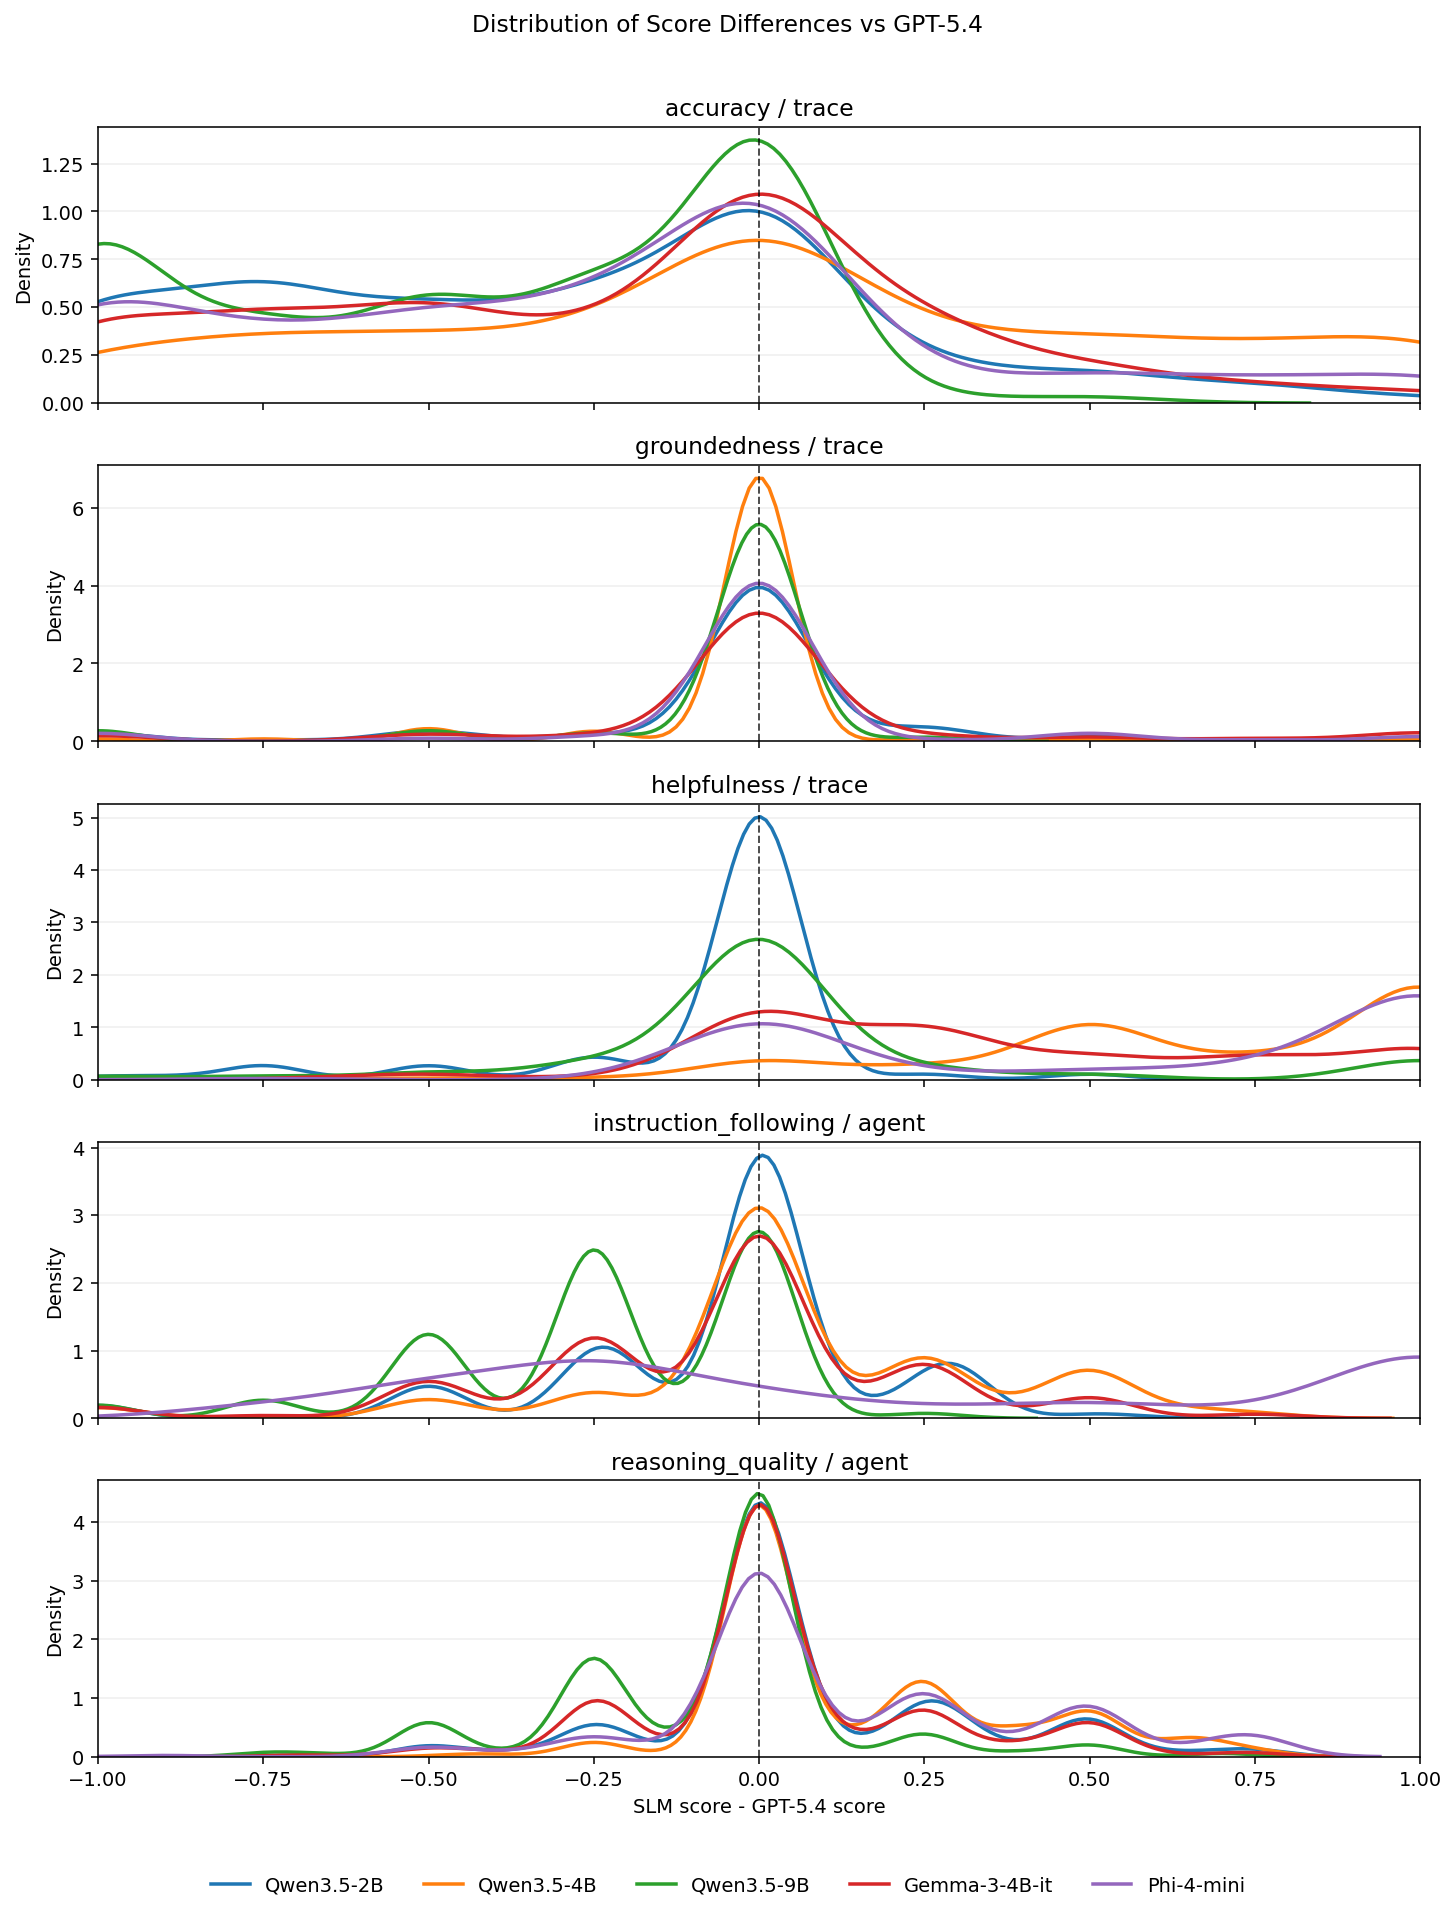

In [34]:
evaluator_order = [c for c in preferred_evaluators if c in delta_df["evaluator_display"].unique()]
model_order = [m for m in preferred_models if m in delta_df["model_display"].unique()]

fig, axes = plt.subplots(len(evaluator_order), 1, figsize=(10.5, 2.7 * len(evaluator_order)), sharex=True)
if len(evaluator_order) == 1:
    axes = [axes]

colors = plt.get_cmap("tab10")
model_colors = {model: colors(i) for i, model in enumerate(model_order)}

for ax, evaluator in zip(axes, evaluator_order):
    subset = delta_df[delta_df["evaluator_display"] == evaluator]
    for model in model_order:
        values = subset.loc[subset["model_display"] == model, "delta"].dropna()
        if len(values) < 3:
            continue
        if HAS_SEABORN:
            sns.kdeplot(
                values,
                ax=ax,
                label=model,
                color=model_colors[model],
                linewidth=1.8,
                bw_adjust=0.7,
                clip=(-1, 1),
            )
        else:
            buckets = np.arange(-1.0, 1.01, 0.25)
            counts = values.round(2).value_counts(normalize=True).reindex(buckets, fill_value=0).sort_index()
            ax.plot(counts.index, counts.values, marker="o", label=model, color=model_colors[model], linewidth=1.8)

    ax.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.7)
    ax.set_title(evaluator)
    ax.set_ylabel("Density")
    ax.grid(axis="y", alpha=0.2)

axes[-1].set_xlabel("SLM score - GPT-5.4 score")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=min(len(model_order), 5), frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.suptitle("Distribution of Score Differences vs GPT-5.4", y=0.995)
plt.xlim(-1, 1)
plt.tight_layout(rect=(0, 0.03, 1, 0.985))

fig_dir = Path("results /figures")
fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_dir / "experiment1_delta_kde_by_evaluator.png", bbox_inches="tight")
fig.savefig(fig_dir / "experiment1_delta_kde_by_evaluator.pdf", bbox_inches="tight")
plt.show()


### Important Observations

**Groundedness is the cleanest trace-level evaluator.**  
Most models have a sharp peak near `0`. Qwen4B and Qwen9B look especially concentrated around GPT-5.4. This suggests groundedness judgments are more stable and easier for SLMs to match.

**Accuracy is noisy.**  
Curves are broad, especially for Qwen4B, Gemma, and Phi. Some models have visible mass far from `0`, meaning accuracy judgments vary substantially case by case. Correlation alone hides this disagreement.

**Helpfulness has strong model-specific bias.**  
Qwen2B peaks near `0`, so it is closest to GPT-5.4 on helpfulness. Qwen4B and Phi have large right-side mass near `+1`, meaning they often score much higher than GPT-5.4. This implies some SLMs are much more generous on helpfulness.

**Instruction-following is where Phi looks weakest.**  
Phi has a wide, multimodal distribution, with mass on both negative and strongly positive deltas. This matches the negative Spearman correlation: Phi is not only noisy on instruction-following; it may rank those cases differently from GPT-5.4.

**Reasoning quality is the strongest evaluator overall.**  
Most models peak sharply around `0`. Qwen2B, Qwen4B, and Gemma stay close to GPT-5.4 with only moderate side peaks. This supports the conclusion that SLMs are most reliable on agent-level `reasoning_quality`.

**Qwen9B is not uniformly better.**  
It has visible negative modes around `-0.25` and `-0.5` for `instruction_following` and `reasoning_quality`. Bigger is not automatically better in this setup.

**How to interpret variance here.**  
Lower variance means the model's difference from GPT-5.4 is more consistent across rows. This is useful only when the distribution is also centered near `0`; a narrow curve far from `0` would mean the model is consistently biased rather than consistently accurate.


### Why These Patterns Are Plausible Given the Evaluator Rubrics

The observed distributions line up with how the evaluators are defined in `llm_judge.py`.

**Groundedness is cleaner because it is evidence-bound.**  
The groundedness prompt gives the judge the agent response plus explicit tool/retrieval evidence, then asks it to classify claims as supported, unsupported, or contradicted. This makes the task more constrained than open-ended factual checking. That likely explains why most models cluster near GPT-5.4 on groundedness.

**Accuracy is noisier because it uses the judge model's own knowledge.**  
The accuracy evaluator explicitly says it assesses factual correctness using the LLM's own knowledge and does not use tool/retrieval evidence. Different SLMs have different knowledge coverage and calibration, so they can disagree with GPT-5.4 even when evaluating the same response.

**Helpfulness is subjective and utility-based.**  
The helpfulness evaluator asks whether the response gives actionable, useful content and leaves the user better off. This is less anchored than groundedness. Some SLMs appear more generous because they may reward partial usefulness or plausible effort more than GPT-5.4 does.

**Instruction-following is complex because it combines many constraints.**  
The instruction-following evaluator asks the judge to inspect system prompt constraints, user request, task description, success criteria, final response, and execution steps. That is a long, multi-source compliance judgment. The broad/multimodal Phi distribution suggests it inconsistently weighs those constraints.

**Reasoning quality is strong because the rubric is process-oriented and the trace exposes the process.**  
The reasoning-quality evaluator focuses on whether execution steps are logical, purposeful, and contribute to the goal. Since agent traces show the sequence of actions, SLMs can often judge this from visible process patterns rather than needing external factual knowledge.

**Lower variance means consistency, not automatically correctness.**  
A narrow distribution near `0` means the SLM consistently agrees with GPT-5.4. A narrow distribution away from `0` would mean consistent bias. Therefore, variance should be interpreted together with `mean_delta`, `MAE`, and the share of rows within one score step of GPT-5.4.


## Discrete Delta Distribution

Because scores are bucketed, this plot is often more faithful than KDE. Each line shows the percentage of rows at each exact score difference bucket.

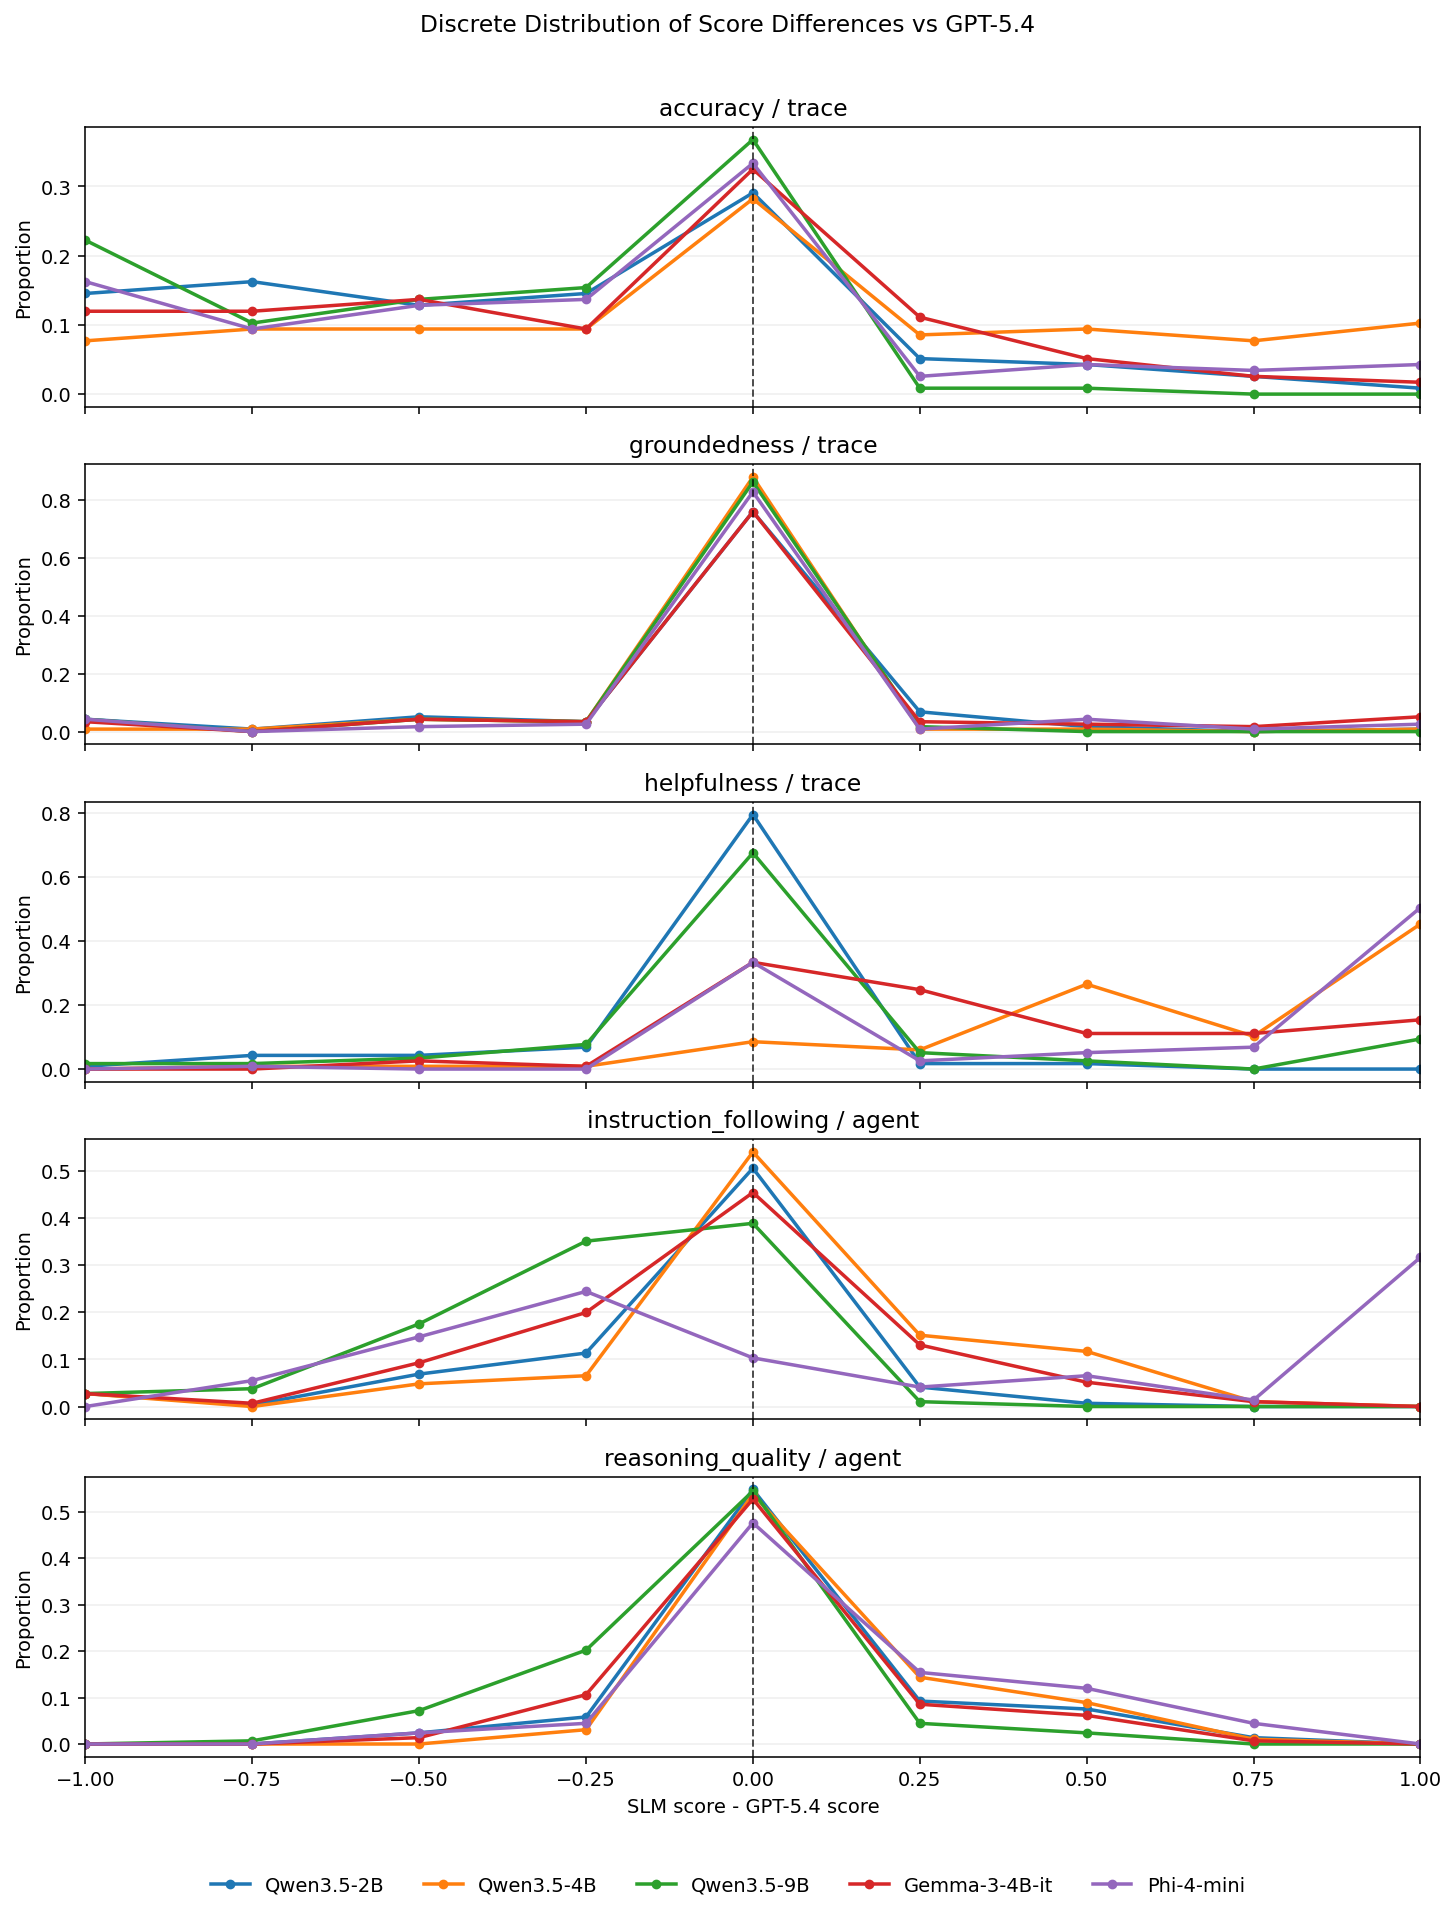

In [35]:
delta_buckets = np.arange(-1.0, 1.01, 0.25)

fig, axes = plt.subplots(len(evaluator_order), 1, figsize=(10.5, 2.7 * len(evaluator_order)), sharex=True)
if len(evaluator_order) == 1:
    axes = [axes]

for ax, evaluator in zip(axes, evaluator_order):
    subset = delta_df[delta_df["evaluator_display"] == evaluator]
    for model in model_order:
        values = subset.loc[subset["model_display"] == model, "delta"].round(2).dropna()
        if values.empty:
            continue
        proportions = values.value_counts(normalize=True).reindex(delta_buckets, fill_value=0).sort_index()
        ax.plot(
            proportions.index,
            proportions.values,
            marker="o",
            markersize=4,
            linewidth=1.8,
            label=model,
            color=model_colors[model],
        )
    ax.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.7)
    ax.set_title(evaluator)
    ax.set_ylabel("Proportion")
    ax.grid(axis="y", alpha=0.2)

axes[-1].set_xlabel("SLM score - GPT-5.4 score")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=min(len(model_order), 5), frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.suptitle("Discrete Distribution of Score Differences vs GPT-5.4", y=0.995)
plt.xlim(-1, 1)
plt.tight_layout(rect=(0, 0.03, 1, 0.985))

fig.savefig(fig_dir / "experiment1_delta_discrete_distribution_by_evaluator.png", bbox_inches="tight")
fig.savefig(fig_dir / "experiment1_delta_discrete_distribution_by_evaluator.pdf", bbox_inches="tight")
plt.show()


In [36]:
corr_df[["model_display", "evaluator_display", "n", "spearman", "pearson", "mean_delta", "mae"]].round(3)


,model_display,evaluator_display,n,spearman,pearson,mean_delta,mae
15,Gemma-3-4B-it,accuracy / trace,117,0.129,0.158,-0.212,0.391
16,Gemma-3-4B-it,groundedness / trace,117,0.126,0.248,0.021,0.150
17,Gemma-3-4B-it,helpfulness / trace,117,0.203,0.185,0.334,0.375
18,Gemma-3-4B-it,instruction_following / agent,291,0.551,0.496,-0.061,0.199
19,Gemma-3-4B-it,reasoning_quality / agent,292,0.831,0.742,0.039,0.140
20,Phi-4-mini,accuracy / trace,117,0.139,0.134,-0.235,0.427
21,Phi-4-mini,groundedness / trace,117,0.352,0.380,-0.002,0.113
22,Phi-4-mini,helpfulness / trace,117,0.270,0.223,0.582,0.595
23,Phi-4-mini,instruction_following / agent,291,-0.464,-0.357,0.197,0.550
24,Phi-4-mini,reasoning_quality / agent,292,0.769,0.729,0.135,0.201


## Explanation Similarity with OpenAI Embeddings

This section compares each SLM explanation against the GPT-5.4 explanation for the same shared-set job. It uses `text-embedding-3-small`, caches embeddings locally, and writes a final explanation-similarity CSV for analysis.

In [39]:
from hashlib import sha256
import json
import time

try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    print("python-dotenv is not installed; relying on existing environment variables.")

try:
    from openai import OpenAI
except ImportError as exc:
    raise ImportError("Install the OpenAI SDK first: pip install openai python-dotenv") from exc

EMBEDDING_MODEL = "text-embedding-3-small"
CACHE_DIR = Path("results /cache")
ANALYSIS_DIR = Path("results /analysis")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

EMBEDDING_CACHE_PATH = CACHE_DIR / f"explanation_embeddings_{EMBEDDING_MODEL}.jsonl"
EXPLANATION_SIMILARITY_PATH = ANALYSIS_DIR / f"explanation_similarity_{EMBEDDING_MODEL}.csv"

client = OpenAI()


In [40]:
def text_key(text: str, model: str = EMBEDDING_MODEL) -> str:
    normalized = " ".join(str(text or "").split())
    return sha256(f"{model}\n{normalized}".encode("utf-8")).hexdigest()


def load_embedding_cache(path: Path) -> dict:
    cache = {}
    if not path.exists():
        return cache
    with path.open("r", encoding="utf-8") as handle:
        for line in handle:
            if not line.strip():
                continue
            item = json.loads(line)
            cache[item["key"]] = item["embedding"]
    return cache


def append_embedding_cache(path: Path, records: list[dict]) -> None:
    if not records:
        return
    with path.open("a", encoding="utf-8") as handle:
        for record in records:
            handle.write(json.dumps(record) + "\n")


def embed_texts_with_cache(texts: list[str], batch_size: int = 128) -> dict[str, list[float]]:
    cache = load_embedding_cache(EMBEDDING_CACHE_PATH)
    unique_texts = []
    seen = set()
    for text in texts:
        normalized = " ".join(str(text or "").split())
        if not normalized:
            continue
        key = text_key(normalized)
        if key not in cache and key not in seen:
            unique_texts.append(normalized)
            seen.add(key)

    print(f"Embedding cache entries: {len(cache)}")
    print(f"New texts to embed: {len(unique_texts)}")

    for start in range(0, len(unique_texts), batch_size):
        batch = unique_texts[start : start + batch_size]
        response = client.embeddings.create(
            model=EMBEDDING_MODEL,
            input=batch,
            encoding_format="float",
        )
        new_records = []
        for text, item in zip(batch, response.data):
            key = text_key(text)
            embedding = item.embedding
            cache[key] = embedding
            new_records.append({"key": key, "model": EMBEDDING_MODEL, "text": text, "embedding": embedding})
        append_embedding_cache(EMBEDDING_CACHE_PATH, new_records)
        print(f"Embedded {min(start + batch_size, len(unique_texts))}/{len(unique_texts)}")
        time.sleep(0.1)

    return cache


def cosine_similarity(a, b) -> float:
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    if denom == 0:
        return np.nan
    return float(np.dot(a, b) / denom)


In [41]:
# Build row-level GPT-vs-SLM explanation pairs on the same shared job set used above.
gpt_full = add_job_identity(pd.read_csv(GPT_PATH))
gpt_full["gpt_score"] = pd.to_numeric(gpt_full["score"], errors="coerce")
gpt_valid = gpt_full.loc[
    (~skipped_mask(gpt_full)) & gpt_full["gpt_score"].between(0, 1) & gpt_full["job_id"].isin(common_job_ids),
    ["job_id", "trace_id", "evaluator", "level", "occurrence_index", "gpt_score", "explanation"],
].rename(columns={"explanation": "gpt_explanation"})

pair_frames = []
for path in model_paths:
    raw = add_job_identity(pd.read_csv(path))
    model_id = raw["model"].dropna().iloc[0]
    if model_id == "gpt-5.4":
        continue
    raw["slm_score"] = pd.to_numeric(raw["score"], errors="coerce")
    valid = raw.loc[
        (~skipped_mask(raw)) & raw["slm_score"].between(0, 1) & raw["job_id"].isin(common_job_ids),
        ["job_id", "slm_score", "explanation"],
    ].rename(columns={"explanation": "slm_explanation"})
    merged = gpt_valid.merge(valid, on="job_id", how="inner")
    merged["model"] = model_id
    merged["model_display"] = clean_model_name(model_id)
    merged["score_delta"] = merged["slm_score"] - merged["gpt_score"]
    merged["abs_score_delta"] = merged["score_delta"].abs()
    merged["score_agreement"] = 1 - merged["abs_score_delta"]
    merged["evaluator_display"] = merged["evaluator"] + " / " + merged["level"]
    pair_frames.append(merged)

explanation_pairs = pd.concat(pair_frames, ignore_index=True)
print("Explanation pairs:", len(explanation_pairs))
explanation_pairs.head()


Explanation pairs: 4670


,job_id,trace_id,evaluator,level,occurrence_index,gpt_score,gpt_explanation,slm_score,slm_explanation,model,model_display,score_delta,abs_score_delta,score_agreement,evaluator_display
0,0035f455b3ff2295167a844f04d85d34|helpfulness|t...,0035f455b3ff2295167a844f04d85d34,helpfulness,trace,0,0.0,The response does not follow the user's reques...,0.0,The agent failed to answer the question by pro...,Qwen/Qwen3.5-2B,Qwen3.5-2B,0.0,0.0,1.0,helpfulness / trace
1,0035f455b3ff2295167a844f04d85d34|accuracy|trace|0,0035f455b3ff2295167a844f04d85d34,accuracy,trace,0,1.0,The likely species is the clownfish/anemonefis...,0.0,The response provides a specific zip code (331...,Qwen/Qwen3.5-2B,Qwen3.5-2B,-1.0,1.0,0.0,accuracy / trace
2,0035f455b3ff2295167a844f04d85d34|groundedness|...,0035f455b3ff2295167a844f04d85d34,groundedness,trace,0,0.0,"The response gives a specific factual answer, ...",0.0,The agent's response provides a specific five-...,Qwen/Qwen3.5-2B,Qwen3.5-2B,0.0,0.0,1.0,groundedness / trace
3,0035f455b3ff2295167a844f04d85d34|instruction_f...,0035f455b3ff2295167a844f04d85d34,instruction_following,agent,0,0.5,"No concrete user request, task description, su...",0.0,The agent failed to provide any response or ex...,Qwen/Qwen3.5-2B,Qwen3.5-2B,-0.5,0.5,0.5,instruction_following / agent
4,0035f455b3ff2295167a844f04d85d34|instruction_f...,0035f455b3ff2295167a844f04d85d34,instruction_following,agent,1,0.5,"The agent ultimately gave a direct answer, but...",0.0,The agent failed to follow the core instructio...,Qwen/Qwen3.5-2B,Qwen3.5-2B,-0.5,0.5,0.5,instruction_following / agent


In [42]:
all_explanations = pd.concat(
    [explanation_pairs["gpt_explanation"], explanation_pairs["slm_explanation"]],
    ignore_index=True,
).fillna("").astype(str).tolist()

embedding_cache = embed_texts_with_cache(all_explanations, batch_size=128)

similarities = []
for _, row in explanation_pairs.iterrows():
    gpt_text = " ".join(str(row["gpt_explanation"] or "").split())
    slm_text = " ".join(str(row["slm_explanation"] or "").split())
    gpt_emb = embedding_cache.get(text_key(gpt_text))
    slm_emb = embedding_cache.get(text_key(slm_text))
    similarities.append(cosine_similarity(gpt_emb, slm_emb) if gpt_emb is not None and slm_emb is not None else np.nan)

explanation_pairs["explanation_similarity"] = similarities
explanation_pairs.to_csv(EXPLANATION_SIMILARITY_PATH, index=False)
print(f"Wrote {EXPLANATION_SIMILARITY_PATH}")
explanation_pairs[["model_display", "evaluator_display", "gpt_score", "slm_score", "abs_score_delta", "explanation_similarity"]].head()


Embedding cache entries: 0
New texts to embed: 4362
Embedded 128/4362
Embedded 256/4362
Embedded 384/4362
Embedded 512/4362
Embedded 640/4362
Embedded 768/4362
Embedded 896/4362
Embedded 1024/4362
Embedded 1152/4362
Embedded 1280/4362
Embedded 1408/4362
Embedded 1536/4362
Embedded 1664/4362
Embedded 1792/4362
Embedded 1920/4362
Embedded 2048/4362
Embedded 2176/4362
Embedded 2304/4362
Embedded 2432/4362
Embedded 2560/4362
Embedded 2688/4362
Embedded 2816/4362
Embedded 2944/4362
Embedded 3072/4362
Embedded 3200/4362
Embedded 3328/4362
Embedded 3456/4362
Embedded 3584/4362
Embedded 3712/4362
Embedded 3840/4362
Embedded 3968/4362
Embedded 4096/4362
Embedded 4224/4362
Embedded 4352/4362
Embedded 4362/4362
Wrote results /analysis/explanation_similarity_text-embedding-3-small.csv


,model_display,evaluator_display,gpt_score,slm_score,abs_score_delta,explanation_similarity
0,Qwen3.5-2B,helpfulness / trace,0.0,0.0,0.0,0.602465
1,Qwen3.5-2B,accuracy / trace,1.0,0.0,1.0,0.648166
2,Qwen3.5-2B,groundedness / trace,0.0,0.0,0.0,0.701946
3,Qwen3.5-2B,instruction_following / agent,0.5,0.0,0.5,0.653330
4,Qwen3.5-2B,instruction_following / agent,0.5,0.0,0.5,0.706825


In [43]:
explanation_similarity_summary = (
    explanation_pairs.groupby(["model_display", "evaluator_display"])
    .agg(
        n=("explanation_similarity", "size"),
        mean_explanation_similarity=("explanation_similarity", "mean"),
        median_explanation_similarity=("explanation_similarity", "median"),
        mean_abs_score_delta=("abs_score_delta", "mean"),
        score_expl_similarity_corr=(
            "explanation_similarity",
            lambda s: s.corr(explanation_pairs.loc[s.index, "abs_score_delta"], method="spearman"),
        ),
    )
    .reset_index()
)
explanation_similarity_summary.round(3)


,model_display,evaluator_display,n,mean_explanation_similarity,median_explanation_similarity,mean_abs_score_delta,score_expl_similarity_corr
0,Gemma-3-4B-it,accuracy / trace,117,0.617,0.642,0.391,0.056
1,Gemma-3-4B-it,groundedness / trace,117,0.652,0.663,0.150,-0.002
2,Gemma-3-4B-it,helpfulness / trace,117,0.590,0.604,0.375,-0.532
3,Gemma-3-4B-it,instruction_following / agent,291,0.642,0.660,0.199,-0.270
4,Gemma-3-4B-it,reasoning_quality / agent,292,0.638,0.617,0.140,0.292
5,Phi-4-mini,accuracy / trace,117,0.568,0.576,0.427,0.052
6,Phi-4-mini,groundedness / trace,117,0.621,0.635,0.113,-0.106
7,Phi-4-mini,helpfulness / trace,117,0.496,0.486,0.595,-0.660
8,Phi-4-mini,instruction_following / agent,291,0.626,0.619,0.550,-0.451
9,Phi-4-mini,reasoning_quality / agent,292,0.675,0.709,0.201,-0.665


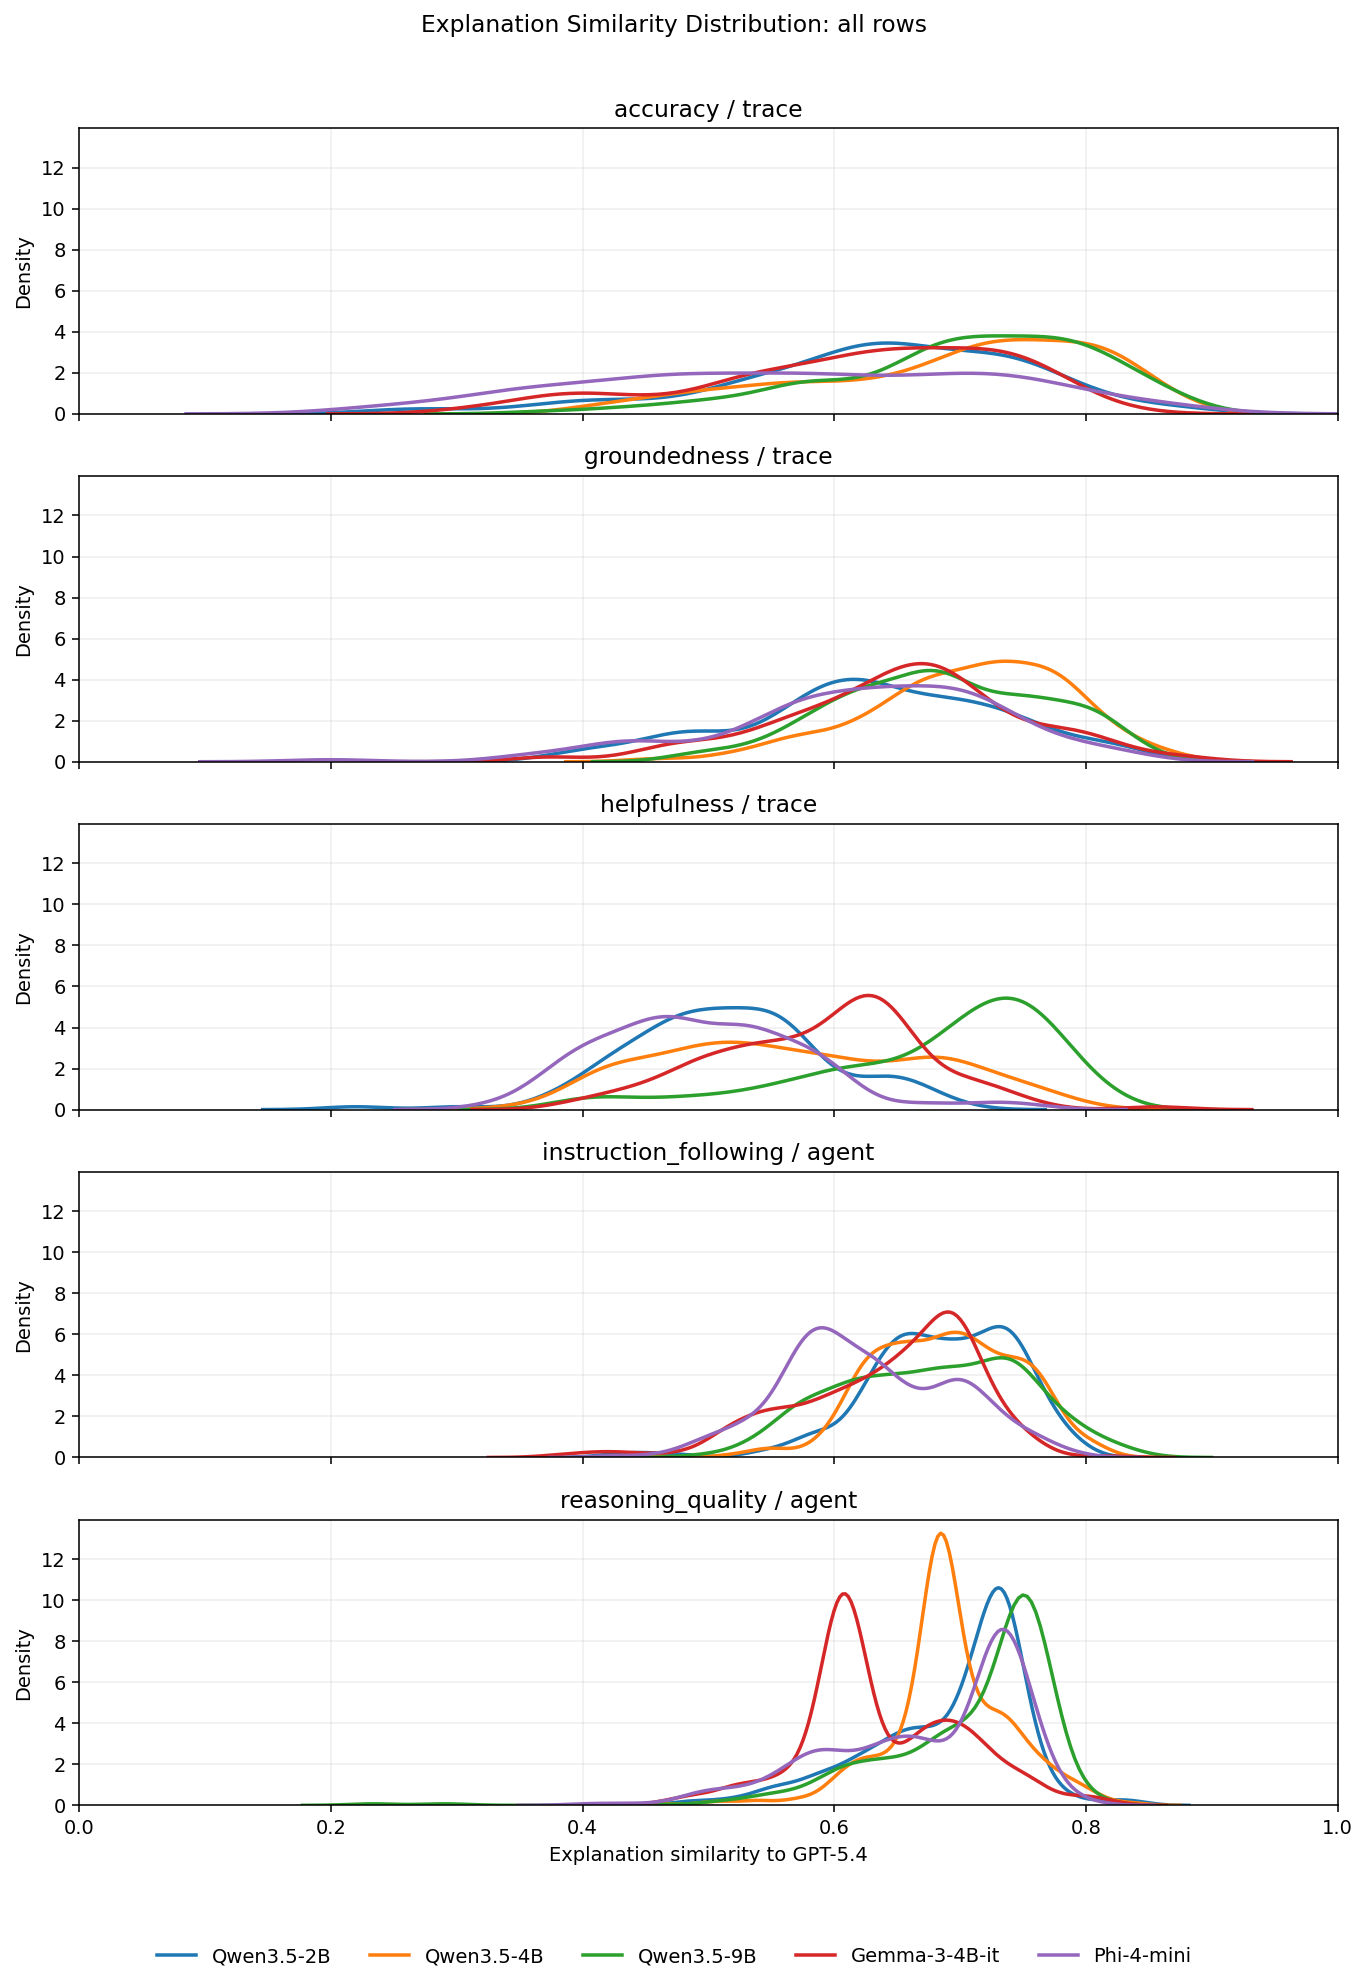

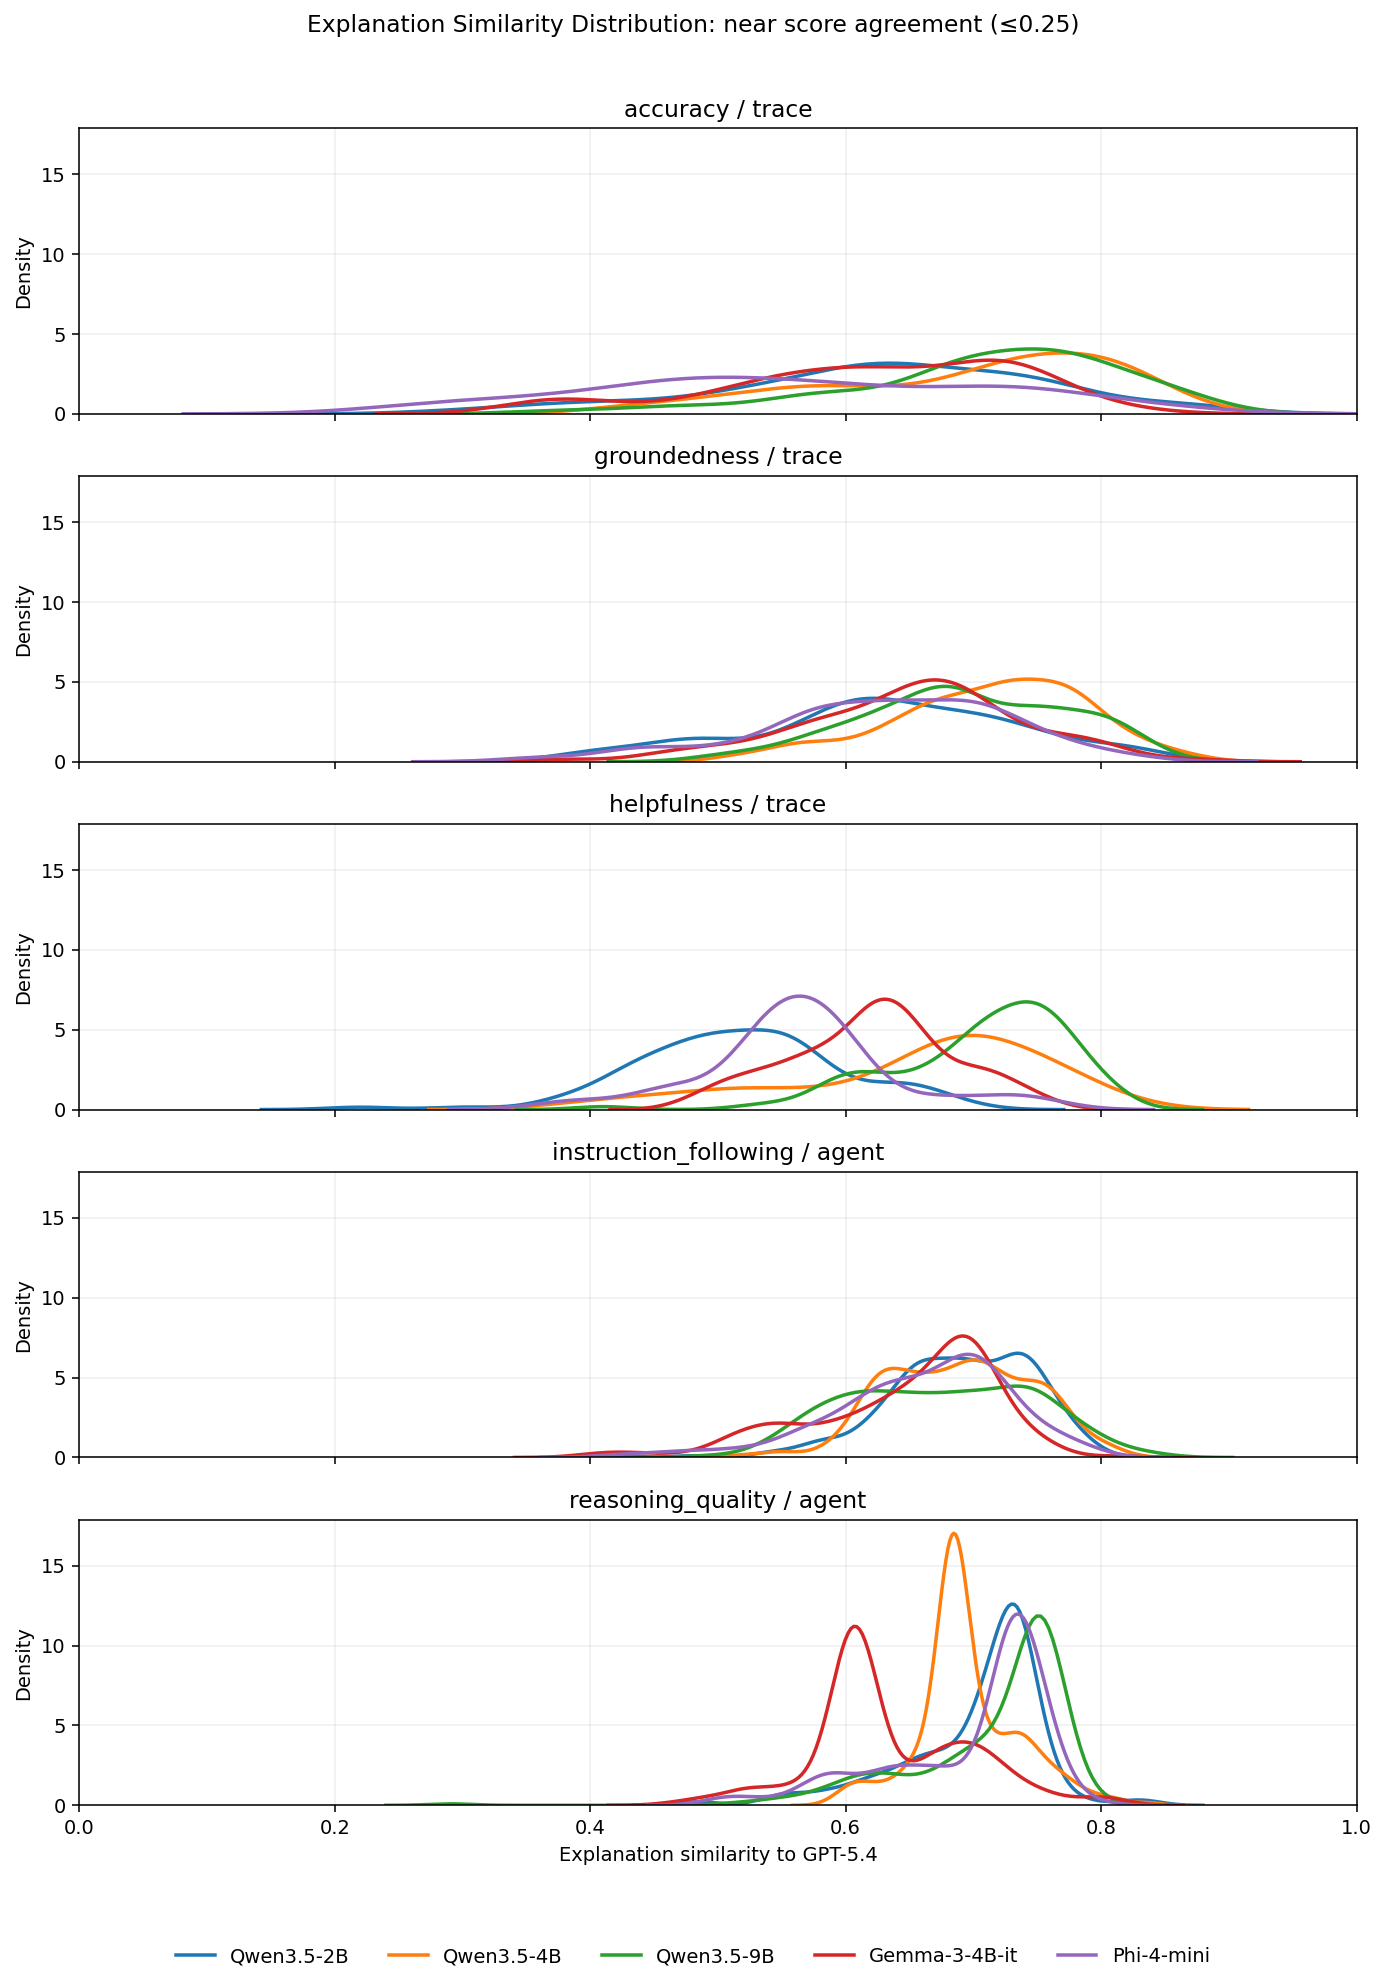

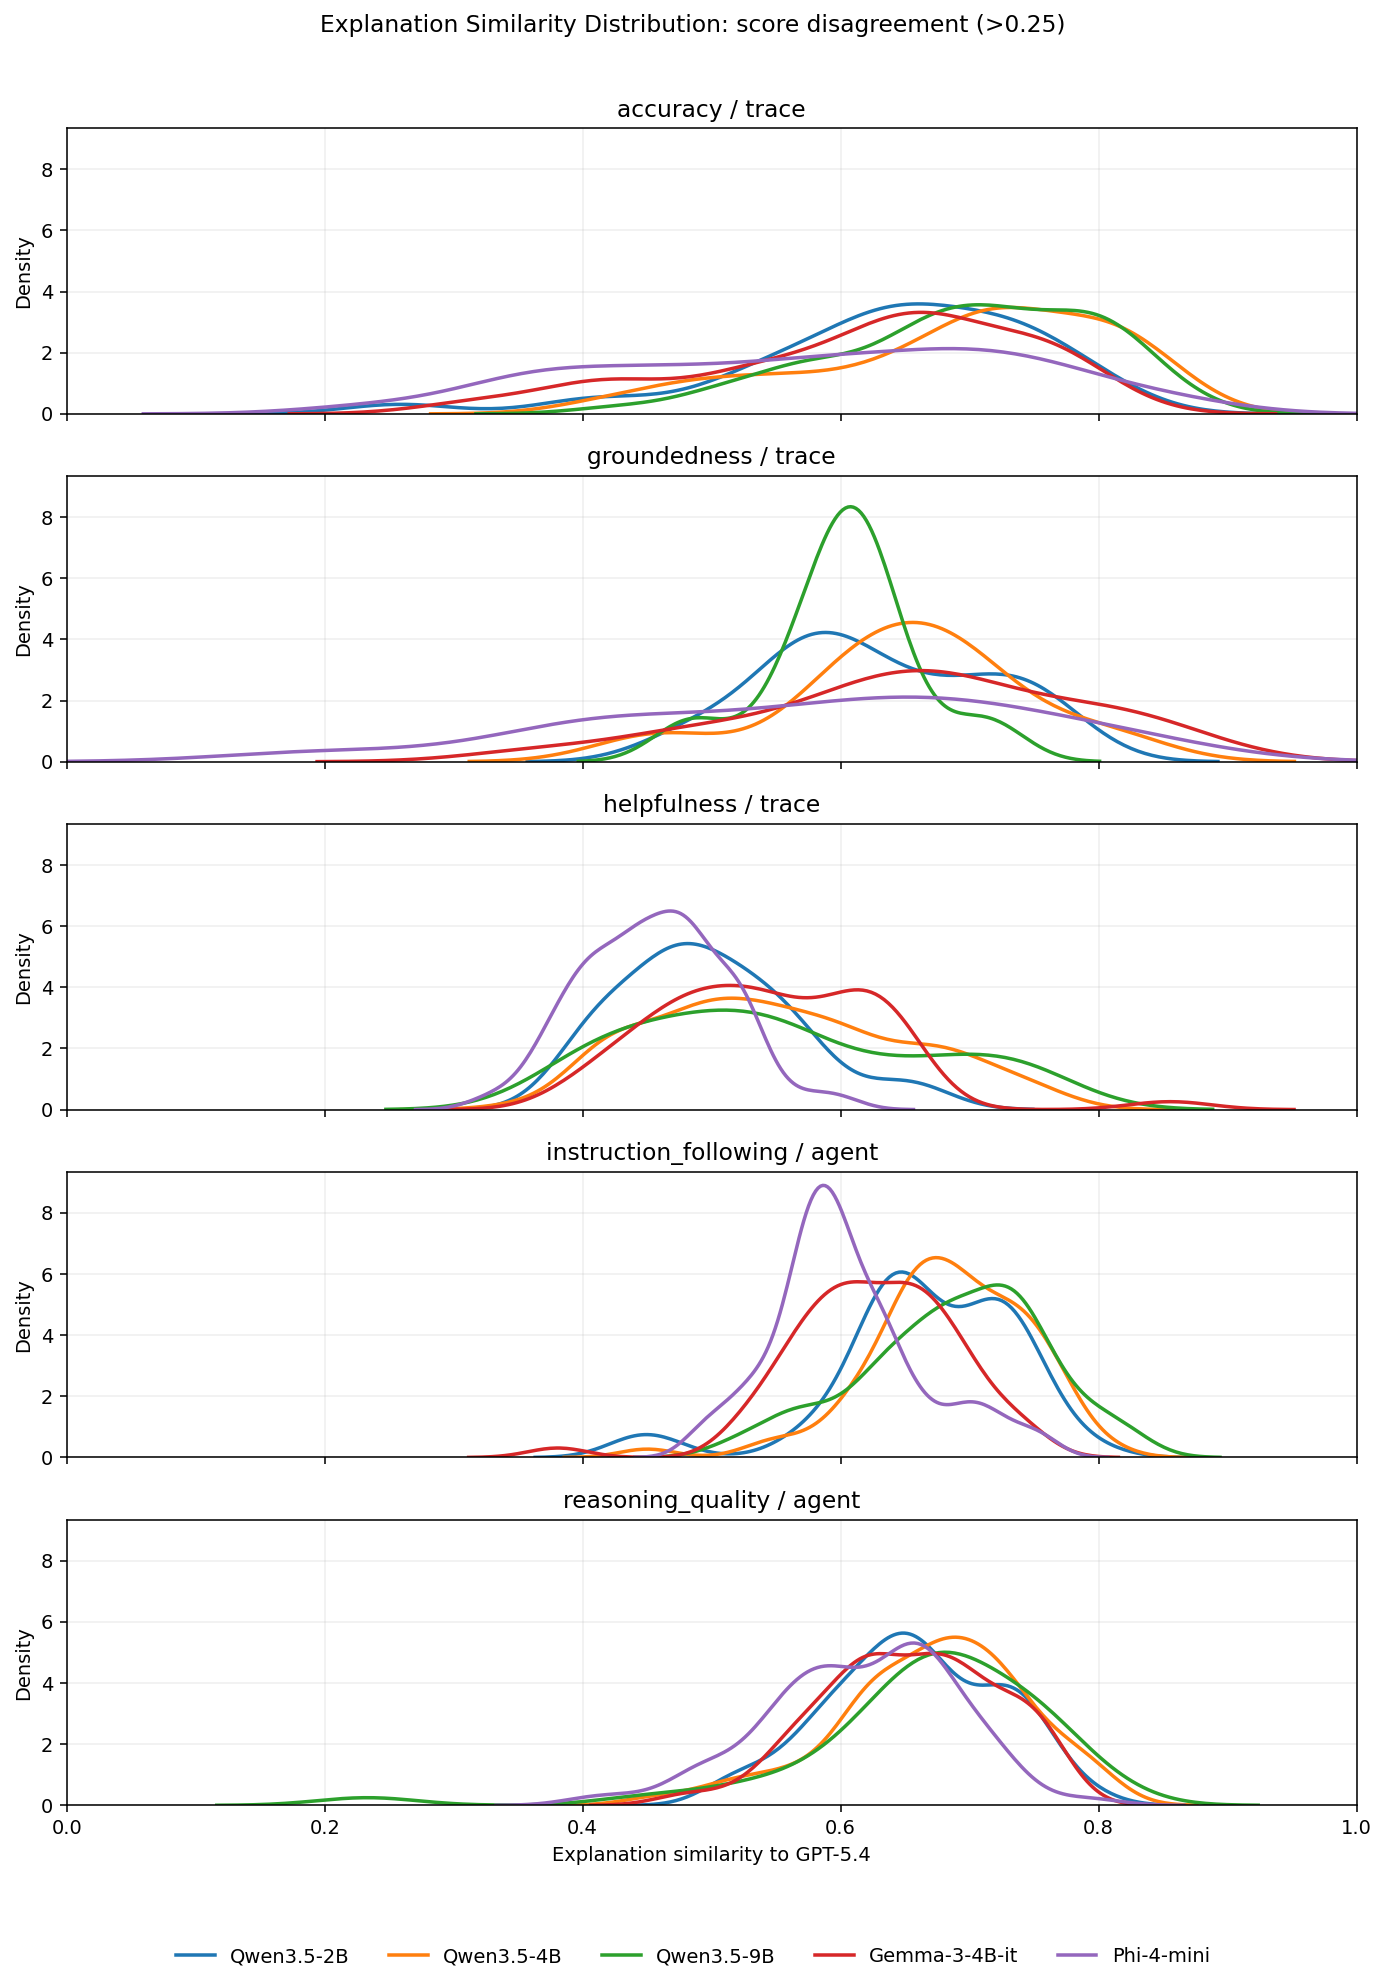

In [47]:
# Explanation similarity density distributions.
# This preserves distribution shape instead of averaging within score-delta buckets.

plot_df = explanation_pairs.dropna(subset=["explanation_similarity", "abs_score_delta"]).copy()

plot_df["score_agreement_group"] = np.where(
    plot_df["abs_score_delta"] <= 0.25,
    "near score agreement (≤0.25)",
    "score disagreement (>0.25)",
)

for group_name, group_df in [
    ("all rows", plot_df),
    ("near score agreement (≤0.25)", plot_df[plot_df["abs_score_delta"] <= 0.25]),
    ("score disagreement (>0.25)", plot_df[plot_df["abs_score_delta"] > 0.25]),
]:
    fig, axes = plt.subplots(
        len(evaluator_order),
        1,
        figsize=(10, 2.8 * len(evaluator_order)),
        sharex=True,
        sharey=True,
    )

    if len(evaluator_order) == 1:
        axes = [axes]

    for ax, evaluator in zip(axes, evaluator_order):
        subset = group_df[group_df["evaluator_display"] == evaluator]

        for model in model_order:
            values = subset.loc[
                subset["model_display"] == model,
                "explanation_similarity",
            ].dropna()

            if len(values) < 3:
                continue

            if HAS_SEABORN:
                sns.kdeplot(
                    values,
                    ax=ax,
                    label=model,
                    color=model_colors.get(model),
                    linewidth=1.8,
                    bw_adjust=0.8,
                    clip=(0, 1),
                )
            else:
                ax.hist(
                    values,
                    bins=np.linspace(0, 1, 21),
                    histtype="step",
                    density=True,
                    label=model,
                    color=model_colors.get(model),
                    linewidth=1.8,
                )

        ax.set_title(evaluator)
        ax.set_ylabel("Density")
        ax.grid(alpha=0.2)

    axes[-1].set_xlabel("Explanation similarity to GPT-5.4")
    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=min(len(model_order), 5),
        frameon=False,
        bbox_to_anchor=(0.5, -0.01),
    )

    safe_group_name = (
        group_name.replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
        .replace("≤", "le")
        .replace(">", "gt")
        .replace(".", "")
    )

    fig.suptitle(f"Explanation Similarity Distribution: {group_name}", y=0.995)
    plt.xlim(0, 1)
    plt.tight_layout(rect=(0, 0.04, 1, 0.985))

    fig.savefig(
        fig_dir / f"experiment1_explanation_similarity_density_{safe_group_name}.png",
        bbox_inches="tight",
    )
    fig.savefig(
        fig_dir / f"experiment1_explanation_similarity_density_{safe_group_name}.pdf",
        bbox_inches="tight",
    )

    plt.show()


### Explanation Similarity Observations

**Overall explanation similarity.**  
Across all rows, most models' explanations are moderately similar to GPT-5.4, usually concentrated around `0.55-0.80`. This means the SLMs are often discussing broadly similar issues, even when their scores are not identical.

**Accuracy.**  
Accuracy explanations are moderately similar across models, but the distributions are broad. This suggests SLMs often identify related factual correctness issues, but the rationale wording and emphasis vary. Phi is shifted lower, meaning its accuracy explanations are less semantically aligned with GPT-5.4.

**Groundedness.**  
Groundedness has relatively strong explanation similarity, especially for Qwen4B and Qwen9B. This matches the earlier score-agreement result: because groundedness is evidence-bound, models tend to produce more similar rationales.

**Helpfulness.**  
Helpfulness shows the most model-specific behavior. Qwen9B has higher explanation similarity, while Qwen2B and Phi are lower. This suggests that even when judging the same helpfulness rubric, models may focus on different aspects of usefulness, partial completion, or actionability.

**Instruction-following.**  
Instruction-following explanations are generally similar for Qwen and Gemma, but Phi is shifted lower and broader. This supports the earlier finding that Phi is less aligned on instruction-following, not only in score but also in rationale.

**Reasoning quality.**  
Reasoning-quality explanations are among the most concentrated and high-similarity distributions for Qwen models. This suggests that SLMs often describe agent reasoning failures/successes similarly to GPT-5.4. Gemma is somewhat lower, while Phi is broader.

**Near score agreement plot.**  
When scores are close to GPT-5.4 (`abs delta <= 0.25`), explanation similarity tends to be higher and more concentrated. This supports the expected relationship: when models numerically agree, their explanations are also more semantically aligned.

**Score disagreement plot.**  
When scores differ meaningfully (`abs delta > 0.25`), explanation similarity does not collapse to zero. Many distributions still sit around `0.55-0.75`. This suggests that some score disagreements are not complete rationale disagreements; they may be calibration differences, where models notice similar issues but assign different severity.

**Important conclusion.**  
The explanation analysis suggests that score disagreement is not always caused by totally different reasoning. In many cases, SLMs and GPT-5.4 produce semantically related explanations but map those rationales to different scores. This is important for interpreting SLM judge reliability: disagreement may reflect score calibration, not just failure to understand the evaluation criterion.
